In [55]:
import numpy as np
import pandas as pd


In [56]:
unemploy = pd.read_csv("C:/Users/sooyo/Downloads/courseworkdata_2425.csv",index_col=0,\
                  parse_dates=[0], na_values =".").dropna()

In [57]:
print(unemploy.shape)
print(unemploy.head)

(194, 2)
<bound method NDFrame.head of             GoogleUnemployment  InitialUnemploymentClaims
Date                                                     
2004-01-01            1.928881                  12.701032
2004-02-01            1.928881                  12.701032
2004-03-01            1.928881                  12.691883
2004-04-01            1.861956                  12.711496
2004-05-01            1.928903                  12.697316
...                        ...                        ...
2019-10-01            1.910392                  12.711145
2019-11-01            1.918116                  12.756348
2019-12-01            2.102923                  12.787041
2020-01-01            2.068385                  12.692998
2020-02-01            2.037655                  12.672828

[194 rows x 2 columns]>


In [58]:
x_t = unemploy['GoogleUnemployment'].dropna()
y_t = unemploy['InitialUnemploymentClaims'].dropna()

In [336]:
date_range = pd.date_range(start="2014-01-01", periods=len(y_t), freq="MS")  # (Month Start)
y_t.index = date_range  # 명확한 주기 설정

date_range = pd.date_range(start="2014-01-01", periods=len(x_t), freq="MS")  # (Month Start)
x_t.index = date_range  # 명확한 주기 설정

In [60]:
from matplotlib import pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## 1- 1. Check Covariance Stationarity of Google Trends Data(x)

#### (1) Plot ACF and PACF 

Text(0.5, 1.0, 'PACF Plot (Google Unemployment)')

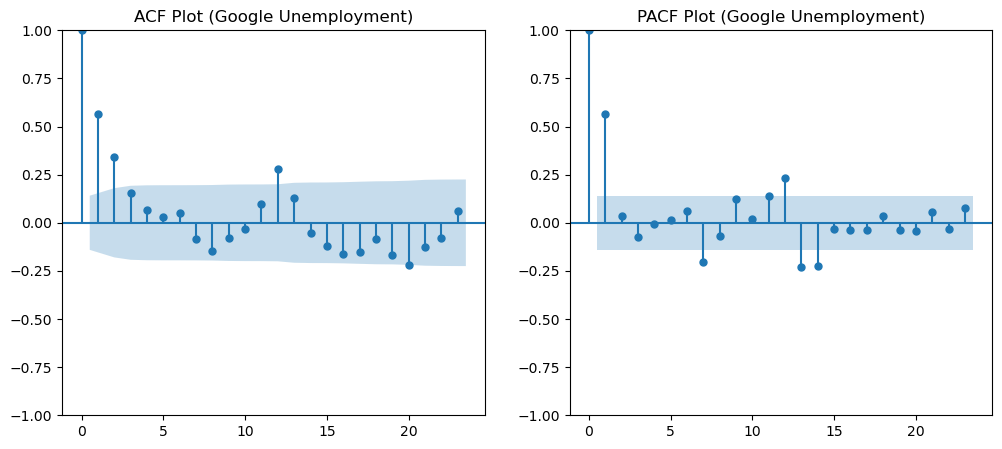

In [149]:
# Select time series data

# Plot ACF and PACF (e.g., for unemployment claims data)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ACF plot
plot_acf(x_t, ax=axes[0])
axes[0].set_title("ACF Plot (Google Unemployment)")

# PACF plot
plot_pacf(x_t, ax=axes[1])
axes[1].set_title("PACF Plot (Google Unemployment)")



#### (2) ADF test

In [155]:
# Configuration 1: ADF test with constant only (regression='c') using explicit maxlag

from statsmodels.tsa.stattools import adfuller

# Perform ADF test with up to 10 lags
lags = range(11)
results = []

for lag in lags:
    result_x = adfuller(x_t, maxlag=lag)
    results.append(result_x[1])

# Print the p-values for each lag
for lag, p_value in zip(lags, results):
    print(f"Lag {lag}: p-value = {p_value}")

print("ADF Statistic:", result_x[0])
print("p-value:", result_x[1])

# If p-value > 0.05, the series lacks stationarity, so differencing is needed
if result_x[1] > 0.05:
    x_t = x_t.diff().dropna()  # Apply differencing


Lag 0: p-value = 1.565382538978244e-10
Lag 1: p-value = 1.565382538978244e-10
Lag 2: p-value = 1.565382538978244e-10
Lag 3: p-value = 1.565382538978244e-10
Lag 4: p-value = 1.565382538978244e-10
Lag 5: p-value = 1.565382538978244e-10
Lag 6: p-value = 1.565382538978244e-10
Lag 7: p-value = 1.565382538978244e-10
Lag 8: p-value = 1.565382538978244e-10
Lag 9: p-value = 1.565382538978244e-10
Lag 10: p-value = 1.565382538978244e-10
ADF Statistic: -7.273577343461537
p-value: 1.565382538978244e-10


In [164]:
# Configuration 2: ADF test with constant + trend (regression='ct') using explicit maxlag
from statsmodels.tsa.stattools import adfuller
result_x = adfuller(x_t, maxlag=lag, regression='ct') 

# Perform ADF test with up to 10 lags
lags = range(11)
results = []

for lag in lags:
    result_x = adfuller(x_t, maxlag=lag)
    results.append(result_x[1])

# Print the p-values
for lag, p_value in zip(lags, results):
    print(f"Lag {lag}: p-value = {p_value}")

print("ADF Statistic:", result_x[0])
print("p-value:", result_x[1])

# If p-value > 0.05, the series lacks stationarity, so differencing is needed
if result_x[1] > 0.05:
    x_t = x_t.diff().dropna()  # Apply differencing

Lag 0: p-value = 1.565382538978244e-10
Lag 1: p-value = 1.565382538978244e-10
Lag 2: p-value = 1.565382538978244e-10
Lag 3: p-value = 1.565382538978244e-10
Lag 4: p-value = 1.565382538978244e-10
Lag 5: p-value = 1.565382538978244e-10
Lag 6: p-value = 1.565382538978244e-10
Lag 7: p-value = 1.565382538978244e-10
Lag 8: p-value = 1.565382538978244e-10
Lag 9: p-value = 1.565382538978244e-10
Lag 10: p-value = 1.565382538978244e-10
ADF Statistic: -7.273577343461537
p-value: 1.565382538978244e-10


In [166]:
# Configuration 3: ADF test with autolag='BIC' and regression='ct'

from statsmodels.tsa.stattools import adfuller
result_x = adfuller(x_t, autolag='BIC', regression='ct')  

# Perform ADF test with up to 10 lags
lags = range(11)
results = []

for lag in lags:
    result_x = adfuller(x_t, maxlag=lag)
    results.append(result_x[1])

# Print the p-values
for lag, p_value in zip(lags, results):
    print(f"Lag {lag}: p-value = {p_value}")

print("ADF Statistic:", result_x[0])
print("p-value:", result_x[1])

# If p-value > 0.05, the series lacks stationarity, so differencing is needed
if result_x[1] > 0.05:
    x_t = x_t.diff().dropna() # Apply differencing

Lag 0: p-value = 1.565382538978244e-10
Lag 1: p-value = 1.565382538978244e-10
Lag 2: p-value = 1.565382538978244e-10
Lag 3: p-value = 1.565382538978244e-10
Lag 4: p-value = 1.565382538978244e-10
Lag 5: p-value = 1.565382538978244e-10
Lag 6: p-value = 1.565382538978244e-10
Lag 7: p-value = 1.565382538978244e-10
Lag 8: p-value = 1.565382538978244e-10
Lag 9: p-value = 1.565382538978244e-10
Lag 10: p-value = 1.565382538978244e-10
ADF Statistic: -7.273577343461537
p-value: 1.565382538978244e-10


#### (3) KPSS test

In [168]:
# Configuration 1: KPSS test with constant only (regression='c') 
from statsmodels.tsa.stattools import kpss

kpss_stat, p_value, _, _ = kpss(x_t, regression='c', nlags=11)
print(f"KPSS Test Statistic: {kpss_stat:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("KPSS Test: Non-stationary (Normality not satisfied)")
else:
    print("KPSS Test: Stationary (Normality satisfied)")


KPSS Test Statistic: 0.0978, p-value: 0.1000
KPSS Test: Stationary (Normality satisfied)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16036\2171768698.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, _, _ = kpss(x_t, regression='c', nlags=11)


In [68]:
# Configuration 2: KPSS test with constant + trend (regression='ct')
from statsmodels.tsa.stattools import kpss

kpss_stat, p_value, _, _ = kpss(x_t, regression='ct', nlags=11)
print(f"KPSS Test Statistic: {kpss_stat:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("KPSS Test: Non-stationary (Normality not satisfied)")
else:
    print("KPSS Test: Stationary (Normality satisfied)")


KPSS Test Statistic: 0.0874, p-value: 0.1000
KPSS Test: Stationary (Normality satisfied)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16036\2739420483.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, _, _ = kpss(x_t, regression='ct', nlags=11)


## 1- 2. Check Covariance Stationarity of Unemployment Claims(y)

#### 1-2.(1) Plot ACF and PACF 

Text(0.5, 1.0, 'PACF Plot (Unemployment Claims)')

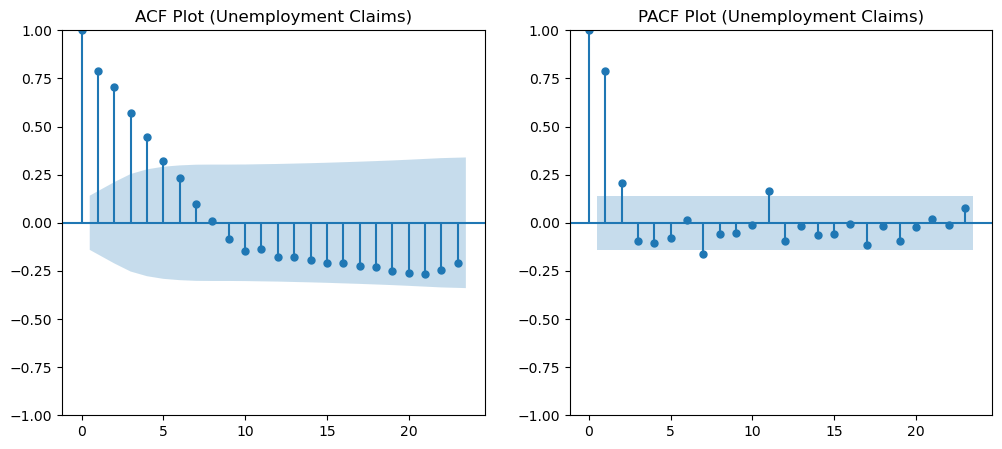

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ACF plot
plot_acf(y_t, ax=axes[0])
axes[0].set_title("ACF Plot (Unemployment Claims)")

# PACF plot
plot_pacf(y_t, ax=axes[1])
axes[1].set_title("PACF Plot (Unemployment Claims)")

####  1-2.(2) ADF Test

In [76]:
# Configuration 1: ADF test with constant only (regression='c') using explicit maxlag
from statsmodels.tsa.stattools import adfuller

# Perform ADF test with up to 10 lags
lags = range(11)
results = []

for lag in lags:
    result_y = adfuller(y_t, maxlag=lag)
    results.append(result_y[1])

# Print the p-values
for lag, p_value in zip(lags, results):
    print(f"Lag {lag}: p-value = {p_value}")

print("ADF Statistic:", result_y[0])
print("p-value:", result_y[1])

# If p-value > 0.05, the series lacks stationarity, so differencing is needed
if result_y[1] > 0.05:
    y_t = y_t.diff().dropna()  

Lag 0: p-value = 8.29406561141899e-05
Lag 1: p-value = 0.006062260580271983
Lag 2: p-value = 0.0024849475876128273
Lag 3: p-value = 0.0009106254679923033
Lag 4: p-value = 0.0009106254679923033
Lag 5: p-value = 0.0009106254679923033
Lag 6: p-value = 0.0003002728073865559
Lag 7: p-value = 0.0003002728073865559
Lag 8: p-value = 0.0003002728073865559
Lag 9: p-value = 0.0003002728073865559
Lag 10: p-value = 0.0003002728073865559
ADF Statistic: -4.397171409711871
p-value: 0.0003002728073865559


In [78]:
# Configuration 2: ADF test with constant + trend (regression='ct') using explicit maxlag

from statsmodels.tsa.stattools import adfuller
result_y = adfuller(y_t, maxlag=lag, regression='ct')  

# Perform ADF test with up to 10 lags
lags = range(11)
results = []

for lag in lags:
    result_y = adfuller(y_t, maxlag=lag)
    results.append(result_y[1])

# Print the p-values
for lag, p_value in zip(lags, results):
    print(f"Lag {lag}: p-value = {p_value}")

print("ADF Statistic:", result_y[0])
print("p-value:", result_y[1])

# If p-value > 0.05, the series lacks stationarity, so differencing is needed
if result_y[1] > 0.05:
    y_t = y_t.diff().dropna()  

Lag 0: p-value = 8.29406561141899e-05
Lag 1: p-value = 0.006062260580271983
Lag 2: p-value = 0.0024849475876128273
Lag 3: p-value = 0.0009106254679923033
Lag 4: p-value = 0.0009106254679923033
Lag 5: p-value = 0.0009106254679923033
Lag 6: p-value = 0.0003002728073865559
Lag 7: p-value = 0.0003002728073865559
Lag 8: p-value = 0.0003002728073865559
Lag 9: p-value = 0.0003002728073865559
Lag 10: p-value = 0.0003002728073865559
ADF Statistic: -4.397171409711871
p-value: 0.0003002728073865559


In [162]:
# Configuration 3: ADF test with autolag='BIC' and regression='ct'

from statsmodels.tsa.stattools import adfuller
result_y = adfuller(y_t, autolag ='BIC', regression='ct')  

# Perform ADF test with up to 10 lags
lags = range(11)
results = []

for lag in lags:
    result_y = adfuller(y_t, maxlag=lag)
    results.append(result_y[1])

# Print the p-values
for lag, p_value in zip(lags, results):
    print(f"Lag {lag}: p-value = {p_value}")

print("ADF Statistic:", result_y[0])
print("p-value:", result_y[1])

# If p-value > 0.05, the series lacks stationarity, so differencing is needed
if result_y[1] > 0.05:
    y_t = y_t.diff().dropna()  

Lag 0: p-value = 8.29406561141899e-05
Lag 1: p-value = 0.006062260580271983
Lag 2: p-value = 0.0024849475876128273
Lag 3: p-value = 0.0009106254679923033
Lag 4: p-value = 0.0009106254679923033
Lag 5: p-value = 0.0009106254679923033
Lag 6: p-value = 0.0003002728073865559
Lag 7: p-value = 0.0003002728073865559
Lag 8: p-value = 0.0003002728073865559
Lag 9: p-value = 0.0003002728073865559
Lag 10: p-value = 0.0003002728073865559
ADF Statistic: -4.397171409711871
p-value: 0.0003002728073865559


#### (3) KPSS test

In [173]:
# Configuration 1: KPSS test with constant only (regression='c') 
from statsmodels.tsa.stattools import kpss

kpss_stat, p_value, _, _ = kpss(y_t, regression='c', nlags=11)
print(f"KPSS Test Statistic: {kpss_stat:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("KPSS Test: Non-stationary (Normality not satisfied)")
else:
    print("KPSS Test: Stationary (Normality satisfied)")


KPSS Test Statistic: 0.0518, p-value: 0.1000
KPSS Test: Stationary (Normality satisfied)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16036\1460145518.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, _, _ = kpss(y_t, regression='c', nlags=11)


In [178]:
# Configuration 2: KPSS test with constant + trend (regression='ct')
from statsmodels.tsa.stattools import kpss

kpss_stat, p_value, _, _ = kpss(y_t, regression='ct', nlags=11)
print(f"KPSS Test Statistic: {kpss_stat:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("KPSS Test: Non-stationary (Normality not satisfied)")
else:
    print("KPSS Test: Stationary (Normality satisfied)")

KPSS Test Statistic: 0.0511, p-value: 0.1000
KPSS Test: Stationary (Normality satisfied)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16036\1428550510.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, _, _ = kpss(y_t, regression='ct', nlags=11)


# 2. ARMA(p, q) Model to fit Unemployment Claims(y)

#### (1) Information Criteria : Choose BIC and ARMA(1,2) Model

In [85]:
import statsmodels.api as sm

# Define the range of p and q values
p_values = range(1, 11)
q_values = range(1, 11)

# Initialize variables to store the optimal p and q values
best_aic = float('inf')
best_bic = float('inf')
best_p = float("inf")
best_q = float("inf")

# Iterate through all possible combinations of p and q
for p in p_values:
    for q in q_values:
        # Fit the ARIMA model
        model = sm.tsa.ARIMA(y_t, order=(p, 0, q))
        model_fit = model.fit()

        # Calculate the AIC and BIC values
        aic = model_fit.aic
        bic = model_fit.bic

        # Update the optimal p and q values if the current model has lower AIC and BIC values
        if aic < best_aic:
            best_aic = aic
            best_p_aic = p
            best_q_aic = q
        if bic < best_bic:
            best_bic = bic
            best_p_bic = p
            best_q_bic = q

# Print the optimal p and q values
print(f"AIC p: {best_p_aic}, q: {best_q_aic}")
print(f"BIC p: {best_p_bic}, q: {best_q_bic}")

C:\Users\sooyo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\sooyo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\sooyo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\sooyo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\sooyo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

AIC p: 1, q: 10
BIC p: 1, q: 2


C:\Users\sooyo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### (2) ARMA(1,2) model -ACF plot, Ljung-box test, Jarque-Bera test, ARCH-LM test

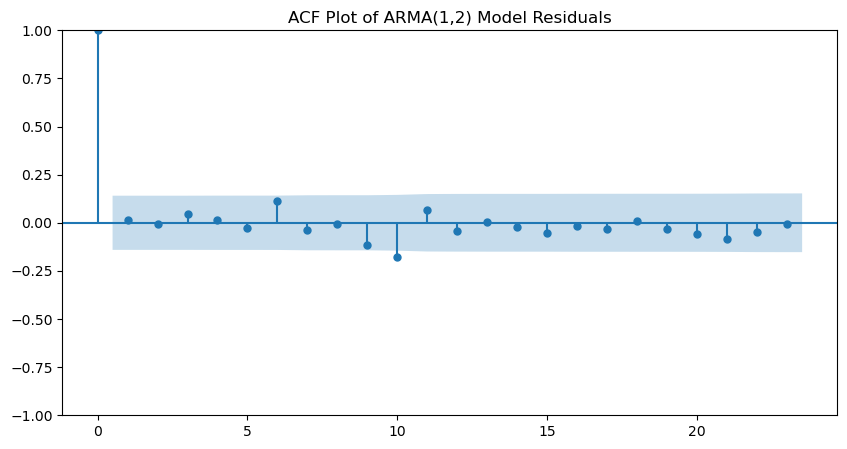


ARMA(1,2) Ljung-Box Test Results:
      lb_stat  lb_pvalue
10  12.877948   0.230576

ARMA(1,2) Jarque-Bera Test Results:
JB Statistic: 58.4513492699894
JB Test p-value: 2.0297884461987924e-13
Skewness: 0.2249881669785982
Kurtosis: 5.651153721293557
ARMA(1,2) ARCH Test Statistic: 19.959812605864002
ARMA(1,2) ARCH Test p-value: 0.029635092776508852
ARMA(1,2) LM Statistic: 2.105000997418947
ARMA(1,2) LM Test p-value: 0.02639375638471289
ARCH effects are present (heteroskedasticity detected) in the ARMA(1,2) model.


In [251]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import numpy as np

# Assume that y_t is your stationary time series (e.g., a pandas Series)
# For ARMA(1,2), we are using ARIMA with order=(1,0,2) because no differencing is applied.

# Fit ARMA(1,2) model
arma_model_12 = sm.tsa.ARIMA(y_t, order=(1, 0, 2)).fit()
residuals_12 = arma_model_12.resid


# -----------------------------
# Plot the ACF of ARMA(1,2) Model Residuals
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(residuals_12, ax=ax)
ax.set_title("ACF Plot of ARMA(1,2) Model Residuals")
plt.show()


# -----------------------------
# Ljung-Box Test for ARMA(1,2)
# -----------------------------
ljung_box_results_12 = acorr_ljungbox(residuals_12, lags=[10], return_df=True)
print("\nARMA(1,2) Ljung-Box Test Results:")
print(ljung_box_results_12)

# -----------------------------
# Jarque-Bera Test for ARMA(1,2)
# -----------------------------
jb_stat_12, jb_pvalue_12, skew_12, kurtosis_12 = jarque_bera(residuals_12)
print("\nARMA(1,2) Jarque-Bera Test Results:")
print(f"JB Statistic: {jb_stat_12}")
print(f"JB Test p-value: {jb_pvalue_12}")
print(f"Skewness: {skew_12}")
print(f"Kurtosis: {kurtosis_12}")

# -----------------------------
# ARCH-LM Test for ARMA(1,2)
# -----------------------------
arch_test_result_12 = het_arch(residuals_12)
arch_stat_12, arch_p_value_12, lm_stat_12, lm_pvalue_12 = arch_test_result_12

print("ARMA(1,2) ARCH Test Statistic:", arch_stat_12)
print("ARMA(1,2) ARCH Test p-value:", arch_p_value_12)
print("ARMA(1,2) LM Statistic:", lm_stat_12)
print("ARMA(1,2) LM Test p-value:", lm_pvalue_12)

if arch_p_value_12 < 0.05:
    print("ARCH effects are present (heteroskedasticity detected) in the ARMA(1,2) model.")
else:
    print("No significant ARCH effects detected (homoskedasticity) in the ARMA(1,2) model.")

## (2-2 * comparison) ARMA(2,2) MODEL  -ACF plot, Ljung-box test, Jarque-Bera test, ARCH-LM test

C:\Users\sooyo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


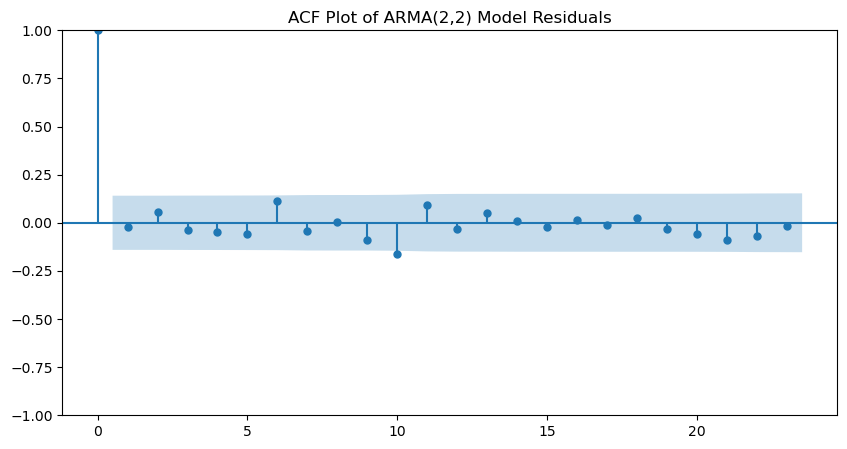


Ljung-Box test results:
      lb_stat  lb_pvalue
10  12.128545   0.276546

Jarque-Bera test results:
JB Statistic: 46.88961521547336
JB Test p-value: 6.577326890801919e-11
Skewness: 0.36538516020437073
Kurtosis: 5.294940495714053
ARCH Test Statistic: 19.441904504624382
ARCH Test p-value: 0.034995809874316754
LM Statistic: 2.043928297283033
LM Test p-value: 0.03161349835513285
ARCH effects are present (heteroskedasticity detected).


In [255]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import numpy as np

# Assume 'data' is your stationary time series (e.g., a pandas Series)
# Fit an ARMA(2,2) model on the series
arma_model_22 = sm.tsa.ARIMA(y_t, order=(2, 0, 2)).fit()
residuals = arma_model_22.resid

# -----------------------------
# Plot the ACF of the residuals
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(residuals, ax=ax)
ax.set_title("ACF Plot of ARMA(2,2) Model Residuals")
plt.show()


# -----------------------------
# Ljung-Box Test
# -----------------------------
# Perform Ljung-Box test on the residuals using lag 10
ljung_box_results = acorr_ljungbox(residuals, lags=[10], return_df=True)
print("\nLjung-Box test results:")
print(ljung_box_results)

# -----------------------------
# Jarque-Bera Test
# -----------------------------
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)
print("\nJarque-Bera test results:")
print(f"JB Statistic: {jb_stat}")
print(f"JB Test p-value: {jb_pvalue}")
print(f"Skewness: {skew}")
print(f"Kurtosis: {kurtosis}")


# -----------------------------
# ARCH-LM Test
# -----------------------------
arch_test_result = het_arch(residuals)
arch_stat, arch_p_value, lm_stat, lm_pvalue = arch_test_result

print("ARCH Test Statistic:", arch_stat)
print("ARCH Test p-value:", arch_p_value)
print("LM Statistic:", lm_stat)
print("LM Test p-value:", lm_pvalue)

if arch_p_value < 0.05:
    print("ARCH effects are present (heteroskedasticity detected).")
else:
    print("No significant ARCH effects detected (homoskedasticity).")

####  (3) Estimate preferred model: ARMA(1,2) Model (Based on Parsimony)

In [257]:
import statsmodels.api as sm
import pandas as pd

# (1) Fit the ARMA(1,2) Model
arma_model_12 = sm.tsa.ARIMA(y_t, order=(1, 0, 2)).fit()

# (2) Extract and Display Model Parameters
print("ARMA(1,2) Model Summary:")
print(arma_model_12.summary())

# Extract parameter estimates
params_12 = arma_model_12.params  # Estimated coefficients
std_errors_12 = arma_model_12.bse  # Standard errors
p_values_12 = arma_model_12.pvalues  # P-values for significance testing

# Create DataFrame for better readability
param_table_12 = pd.DataFrame({
    "Parameter": params_12.index,
    "Estimate": params_12.values,
    "Std Error": std_errors_12.values,
    "p-value": p_values_12.values
})

# Display the parameter table
print("\nARMA(1,2) Parameter Estimates:")
print(param_table_12)

# (3) Interpret the parameter estimates and significance
print("\nInterpretation of Parameter Estimates:")
for index, row in param_table_12.iterrows():
    param_name = row["Parameter"]
    estimate = row["Estimate"]
    p_val = row["p-value"]

    if p_val < 0.05:
        significance = "Statistically Significant (p < 0.05)"
    else:
        significance = "Not Statistically Significant (p >= 0.05)"

    print(f"- {param_name}: {estimate:.4f}, {significance}")

# (4) Evaluating Impact on Previous Analysis
print("\nImpact on Previous Conclusions:")
# If any p-value is high (e.g., above 0.05), the parameter may not contribute much to the model.
if any(p_values_12 > 0.05):
    print("Some parameters are not statistically significant, suggesting that a different model (e.g., changing AR/MA orders) may be considered.")
else:
    print("All parameters appear significant, supporting the selection of the ARMA(1,2) model.")

# Additional Notes:
# - If AR(1) coefficient is close to 1, the series might still contain persistence.
# - If MA(2) term is insignificant, it may indicate that the model complexity can be reduced.


ARMA(1,2) Model Summary:
                                   SARIMAX Results                                   
Dep. Variable:     InitialUnemploymentClaims   No. Observations:                  194
Model:                        ARIMA(1, 0, 2)   Log Likelihood                 382.059
Date:                       Mon, 24 Feb 2025   AIC                           -754.117
Time:                               22:32:21   BIC                           -737.778
Sample:                           01-01-2014   HQIC                          -747.501
                                - 02-01-2030                                         
Covariance Type:                         opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.7013      0.013    953.269      0.000      12.675      12.727
ar.L1          0.8036      0.056     14.238      0

#### (4) Check the stationarity and ergodicity with roots of AR and MA polynomials

In [262]:
# Extract the roots of the AR and MA polynomials
ar_roots = arma_model_12.arroots
ma_roots = arma_model_12.maroots

# Print the roots
print("AR roots:", ar_roots)
print("MA roots:", ma_roots)

AR roots: [1.24439253]
MA roots: [0.42854449-2.15019086j 0.42854449+2.15019086j]


# 3. Distributed Lag Regression Model

## (1) Appropriate number of Lags of xt(Google Trends) to include

In [120]:
ㅇㅇimport pandas as pd
import statsmodels.api as sm
import numpy as np

# --------------------------------------------------
# 1. Data Preparation
# Assume "unemploy" is a DataFrame with a date index, and columns:
# "InitialUnemploymentClaims" (dependent variable)
# "GoogleUnemployment" (independent variable)
# "GoogleUnemployment" will be used to create lagged variables.
# --------------------------------------------------

# (If not already done, ensure your DataFrame 'unemploy' is loaded correctly.)
# For example: unemploy = pd.read_csv('your_file.csv', parse_dates=['date'], index_col='date')

# --------------------------------------------------
# 2. Create lagged variables for "GoogleUnemployment"
# We create lags 1, 2, and 3.
unemploy["GoogleUnemployment_lag1"] = unemploy["GoogleUnemployment"].shift(1)
unemploy["GoogleUnemployment_lag2"] = unemploy["GoogleUnemployment"].shift(2)
unemploy["GoogleUnemployment_lag3"] = unemploy["GoogleUnemployment"].shift(3)

# Drop missing rows caused by lagging
unemploy.dropna(inplace=True)

# --------------------------------------------------
# 3. Distributed Lag Regression Setup (Baseline)
# Define dependent (Y) and independent (X) variables.
Y = unemploy["InitialUnemploymentClaims"].values  # Dependent variable
X = unemploy[["GoogleUnemployment", "GoogleUnemployment_lag1", "GoogleUnemployment_lag2", "GoogleUnemployment_lag3"]]

# (Optionally add a constant if you plan to run regression outside of the loop)
# X = sm.add_constant(X)

# --------------------------------------------------
# 4. Function to Create Lagged Columns for a Series
# This function returns a DataFrame with columns for lag 0 to max_lag.
def create_lags(series, max_lag):
    """
    series: pd.Series
    max_lag: maximum lag (integer)
    return: DataFrame with lag columns (e.g., 'GoogleUnemployment_lag0', 'GoogleUnemployment_lag1', ...)
    """
    data = {}
    for lag in range(max_lag + 1):
        col_name = f"{series.name}_lag{lag}"
        data[col_name] = series.shift(lag)
    return pd.DataFrame(data)

# --------------------------------------------------
# 5. Model Selection for Distributed Lag Regression via AIC/BIC
# We test models with maximum lag from 0 up to max_lag.
max_lag = 3  # Testing lags 0 to 3

best_aic = np.inf
best_bic = np.inf
best_model_aic = None
best_model_bic = None
best_lag_aic = None
best_lag_bic = None

# Loop through each maximum lag value
for lag in range(max_lag + 1):
    # Create lagged columns for the independent variable "GoogleUnemployment"
    X_lags = create_lags(unemploy["GoogleUnemployment"], lag)  # This creates columns like "GoogleUnemployment_lag0", ... "GoogleUnemployment_lag{lag}"
    
    # Merge the dependent variable with the lagged independent variables, drop rows with NaNs
    temp_df = pd.concat([unemploy["InitialUnemploymentClaims"], X_lags], axis=1).dropna()
    Y_temp = temp_df["InitialUnemploymentClaims"]
    
    # Select all lag columns for independent variables
    # Use the prefix of the series name to filter (e.g., "GoogleUnemployment_lag")
    cols = [col for col in temp_df.columns if col.startswith("GoogleUnemployment_lag")]
    X_temp = temp_df[cols]
    
    # Add a constant to the independent variables
    X_temp = sm.add_constant(X_temp)
    
    # Fit the OLS model
    model = sm.OLS(Y_temp, X_temp).fit()
    
    current_aic = model.aic
    current_bic = model.bic
    
    # Update best model based on AIC
    if current_aic < best_aic:
        best_aic = current_aic
        best_model_aic = model
        best_lag_aic = lag
    
    # Update best model based on BIC
    if current_bic < best_bic:ㅇ
        best_bic = current_bic
        best_model_bic = model
        best_lag_bic = lag

print(f"Best AIC model has max lag = {best_lag_aic}, AIC = {best_aic}")
print(best_model_aic.summary())

print(f"\nBest BIC model has max lag = {best_lag_bic}, BIC = {best_bic}")
print(best_model_bic.summary())


Best AIC model has max lag = 3, AIC = -530.8510278514393
                                OLS Regression Results                               
Dep. Variable:     InitialUnemploymentClaims   R-squared:                       0.259
Model:                                   OLS   Adj. R-squared:                  0.241
Method:                        Least Squares   F-statistic:                     14.67
Date:                       Mon, 24 Feb 2025   Prob (F-statistic):           2.69e-10
Time:                               20:34:11   Log-Likelihood:                 270.43
No. Observations:                        173   AIC:                            -530.9
Df Residuals:                            168   BIC:                            -515.1
Df Model:                                  4                                         
Covariance Type:                   nonrobust                                         
                              coef    std err          t      P>|t|      [0.025    

In [271]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Assumptions:
# - The 'unemploy' DataFrame exists
# - Dependent variable: "InitialUnemploymentClaims"
# - Independent variable: "GoogleUnemployment" (lag 0)
# - max_lag = 3 (considering lags from 0 to 3)

# (0) Create lagged variables
max_lag = 3
unemploy["GoogleUnemployment_lag1"] = unemploy["GoogleUnemployment"].shift(1)
unemploy["GoogleUnemployment_lag2"] = unemploy["GoogleUnemployment"].shift(2)
unemploy["GoogleUnemployment_lag3"] = unemploy["GoogleUnemployment"].shift(3)

# Initialize best AIC and BIC values for comparison
best_aic = float('inf')
best_bic = float('inf')
best_results_aic = None
best_results_bic = None
best_lag_aic = None
best_lag_bic = None

for lags in range(max_lag+1):
    # (1) Create a copy of the DataFrame
    df_temp = unemploy.copy()

    # (2) Set higher lag variables to NaN if not considered in the current iteration
    #     Example: If lags=1, set lag2 and lag3 as NaN (not used in the model)
    if lags < 3:
        df_temp["GoogleUnemployment_lag3"] = np.nan
    if lags < 2:
        df_temp["GoogleUnemployment_lag2"] = np.nan
    if lags < 1:
        df_temp["GoogleUnemployment_lag1"] = np.nan

    # (3) Remove rows with NaN values
    df_temp.dropna(inplace=True)
    if len(df_temp) == 0:
        print(f"lags={lags} ⇒ all rows dropped after NaN removal. Skipping.")
        continue

    # (4) Define dependent and independent variables
    Y = df_temp["InitialUnemploymentClaims"].values
    
    # If lag=0, use only "GoogleUnemployment"
    # If lag=1 or more, also include GoogleUnemployment_lag1, ...
    X_cols = ["GoogleUnemployment"]
    if lags >= 1:
        X_cols.append("GoogleUnemployment_lag1")
    if lags >= 2:
        X_cols.append("GoogleUnemployment_lag2")
    if lags >= 3:
        X_cols.append("GoogleUnemployment_lag3")

    X = df_temp[X_cols]
    X = sm.add_constant(X)  # Add intercept term

    # (5) Fit OLS regression model
    model = sm.OLS(Y, X)
    results = model.fit()

    # (6) Compare AIC/BIC values
    current_aic = results.aic
    current_bic = results.bic

    print(f"lags={lags}, n={len(df_temp)} ⇒ AIC={current_aic:.3f}, BIC={current_bic:.3f}")

    if current_aic < best_aic:
        best_aic = current_aic
        best_results_aic = results
        best_lag_aic = lags

    if current_bic < best_bic:
        best_bic = current_bic
        best_results_bic = results
        best_lag_bic = lags

# (Final Results)
print("\n==========================")
print(f"Best AIC model: lags={best_lag_aic}, AIC={best_aic:.3f}")
if best_results_aic is not None:
    print(best_results_aic.summary())

print("\n==========================")
print(f"Best BIC model: lags={best_lag_bic}, BIC={best_bic:.3f}")
if best_results_bic is not None:
    print(best_results_bic.summary())


lags=0 ⇒ all rows dropped after NaN removal. Skipping.
lags=1 ⇒ all rows dropped after NaN removal. Skipping.
lags=2 ⇒ all rows dropped after NaN removal. Skipping.
lags=3, n=170 ⇒ AIC=-520.704, BIC=-505.025

Best AIC model: lags=3, AIC=-520.704
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     14.59
Date:                Mon, 24 Feb 2025   Prob (F-statistic):           3.16e-10
Time:                        22:52:54   Log-Likelihood:                 265.35
No. Observations:                 170   AIC:                            -520.7
Df Residuals:                     165   BIC:                            -505.0
Df Model:                           4                                         
Covariance Type:            nonrobust      

In [273]:
# (1) Data Preparation
# Example DataFrame: Index as dates, containing columns "unemp" and "google"

# (2) Generate lagged variables for up to 3 months
unemploy["GoogleUnemployment_lag1"] = unemploy["GoogleUnemployment"].shift(1)
unemploy["GoogleUnemployment_lag2"] = unemploy["GoogleUnemployment"].shift(2)
unemploy["GoogleUnemployment_lag3"] = unemploy["GoogleUnemployment"].shift(3)

# Remove missing values (due to lag creation at the beginning of the series)
unemploy.dropna(inplace=True)

# (3) Construct Distributed Lag Regression Model
Y = unemploy["InitialUnemploymentClaims"].values  # Dependent variable
X = unemploy[["GoogleUnemployment", "GoogleUnemployment_lag1", "GoogleUnemployment_lag2", "GoogleUnemployment_lag3"]]  # Independent variables

# Add constant term
X = sm.add_constant(X)

# (4) OLS Regression + Newey-West Standard Errors (HAC) with max lag = 3
model = sm.OLS(Y, X)
results1 = model.fit(cov_type='nonrobust')  # Standard OLS
results2 = model.fit(cov_type='HC0')  # Heteroskedasticity-robust standard errors
results3 = model.fit(cov_type='HAC', cov_kwds={'maxlags': 3})  # Newey-West HAC standard errors


## (2) The appropriate Standard Errors to use in the regression

### (2-1) Check Autocorrelation of residuals

#### 1) Breusch Godfrey Test

In [302]:
# Nonrobust Standard Error

from statsmodels.stats.diagnostic import acorr_breusch_godfrey

bg_test_stat_non, bg_test_pvalue_non, _, _ = acorr_breusch_godfrey(results1, nlags=10)
print("BG Test Statistic_nonrobust:", bg_test_stat_non)
print("BG Test p-value_nonrobust:", bg_test_pvalue_non)

# White heteroskedasticity-consistent Standard Error
bg_test_stat_White, bg_test_pvalue_White, _, _ = acorr_breusch_godfrey(results2, nlags=10)
print("BG Test Statistic_White:", bg_test_stat_White)
print("BG Test p-value_White:", bg_test_pvalue_White)

# Newey-West (HAC) Standard Error
bg_test_stat_HAC, bg_test_pvalue_HAC, _, _ = acorr_breusch_godfrey(results3, nlags=10)
print("BG Test Statistic_HAC:", bg_test_stat_HAC)
print("BG Test p-value_HAC:", bg_test_pvalue_HAC)


BG Test Statistic_nonrobust: 102.922736686655
BG Test p-value_nonrobust: 1.4149112583385167e-17
BG Test Statistic_White: 102.922736686655
BG Test p-value_White: 1.4149112583385167e-17
BG Test Statistic_HAC: 102.922736686655
BG Test p-value_HAC: 1.4149112583385167e-17


##### OLS model, specifying different cov_type options (nonrobust, HC0/White, HAC/Newey-West, etc.) only affects how the standard errors (the covariance matrix of the estimated coefficients) are computed. It does not alter the point estimates (i.e., the regression coefficients) or the residuals. 

##### The null hypothesis   of the Breusch-Godfrey (BG) test is that there is no autocorrelation in the residuals (i.e., they are white noise). Because the p-value is extremely small, we reject null hypothetis at any conventional significance level (e.g., 5%). 

#### Thus, we conclude that there is significant autocorrelation in the residuals.

#### 2) ACF Plot

<Figure size 600x400 with 0 Axes>

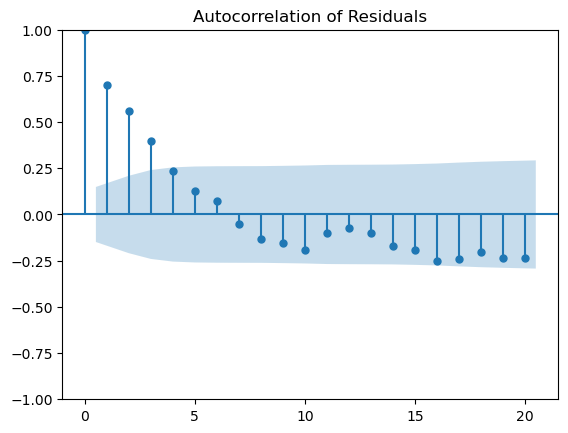

In [287]:
plt.figure(figsize = (6, 4))
plot_acf(residuals1, lags=20, alpha = 0.05)
plt.title('Autocorrelation of Residuals')
plt.show()

### (2-2) Check Heteroscedasticity of residuals

#### 1) Breusch Pagan Test

In [295]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Residuals obtained from the OLS model (identical regardless of cov_type)
resid = results1.resid

# The independent variable matrix X already includes the constant term
bp_test = het_breuschpagan(resid, X)
lm_stat, lm_pvalue, f_stat, f_pvalue = bp_test

print("Breusch-Pagan Test Results (using nonrobust covariance model):")
print("LM Statistic:", lm_stat)
print("LM Test p-value:", lm_pvalue)
print("F Statistic:", f_stat)
print("F Test p-value:", f_pvalue)



Breusch-Pagan Test Results (using nonrobust covariance model):
LM Statistic: 4.626887532502046
LM Test p-value: 0.32776588032669446
F Statistic: 1.1541121036421242
F Test p-value: 0.33310922930962944


#### 2) Regression Model for Squared Residuals

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.154
Date:                Tue, 25 Feb 2025   Prob (F-statistic):              0.333
Time:                        09:00:21   Log-Likelihood:                 678.13
No. Observations:                 170   AIC:                            -1346.
Df Residuals:                     165   BIC:                            -1331.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

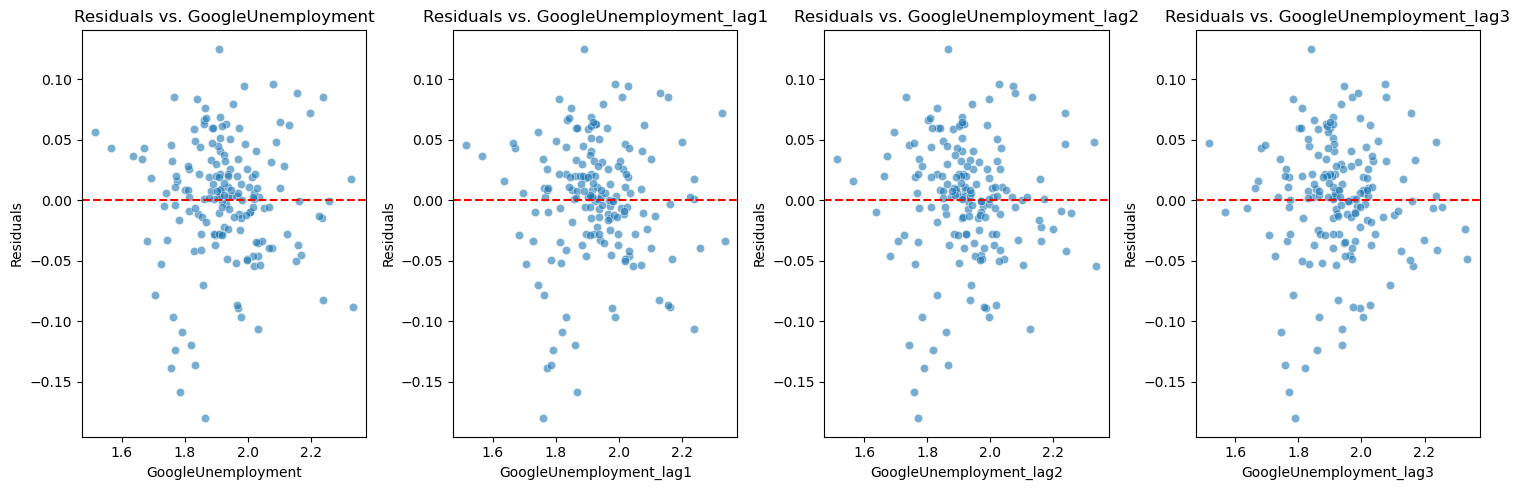

In [308]:
import seaborn as sns

# 1. Extract residuals from the existing OLS model
resid = results1.resid

# 2. Compute the squared residuals
resid_squared = resid ** 2

# 3. Fit a regression model using squared residuals as the dependent variable
#    and the same independent variables (X, including the constant term)
model_resid_sq = sm.OLS(resid_squared, X)
results_resid_sq = model_resid_sq.fit()

# 4. Print the regression results
print(results_resid_sq.summary())

# =============================
# 5. Plot Residuals vs. Independent Variables
# =============================
fig, axes = plt.subplots(nrows=1, ncols=len(X.columns)-1, figsize=(15, 5))

for i, col in enumerate(X.columns[1:]):  # Skip the constant term
    ax = axes[i]
    sns.scatterplot(x=X[col], y=resid, ax=ax, alpha=0.6)
    ax.axhline(y=0, color='red', linestyle='dashed')  # Horizontal reference line at 0
    ax.set_xlabel(col)
    ax.set_ylabel("Residuals")
    ax.set_title(f"Residuals vs. {col}")

plt.tight_layout()
plt.show()




##### The p-values for both LM (0.3278) and F (0.3331) tests are greater than 0.05. This means we fail to reject the null hypothesis. Moreover, residuals are randomly scattered → No major heteroskedasticity detected
#### There is no strong evidence of heteroskedasticity in the residuals.


#### (2-3) ljung Box test to check whether it is white noise

In [132]:
from statsmodels.stats.diagnostic import acorr_ljungbox
residuals1 = results1.resid
lb_test1 = acorr_ljungbox(residuals1, lags=[10], return_df=True)
print(lb_test1)

from statsmodels.stats.diagnostic import acorr_ljungbox
residuals2 = results2.resid
lb_test2 = acorr_ljungbox(residuals2, lags=[10], return_df=True)
print(lb_test2)

from statsmodels.stats.diagnostic import acorr_ljungbox
residuals3 = results3.resid
lb_test3 = acorr_ljungbox(residuals3, lags=[10], return_df=True)
print(lb_test3)


       lb_stat     lb_pvalue
10  198.567812  3.210139e-37
       lb_stat     lb_pvalue
10  198.567812  3.210139e-37
       lb_stat     lb_pvalue
10  198.567812  3.210139e-37


##### “Given the low R-squared, the non-significant F-test, and the high p-values for each coefficient, it suggests that the residual variance does not show a significant relationship with the independent variables

##### I ran a Breusch-Pagan test for heteroscedasticity in the residuals, but the test failed to reject the null hypothesis. But, Breusch-Godfrey test and Ljung test reject the null for serial correlation in the residuals up to lag order 10. 
#### Therefore, I conclude there is serial correlation in the residuals and I use Newey-West standard errors(HAC standard errors) in my regression model

# Interpretation of regression coefficients

In [321]:
# Regresstion using HAC standard errors
print(results3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     4.469
Date:                Tue, 25 Feb 2025   Prob (F-statistic):            0.00187
Time:                        09:08:50   Log-Likelihood:                 265.35
No. Observations:                 170   AIC:                            -520.7
Df Residuals:                     165   BIC:                            -505.0
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

# 4. Structural Break

In [144]:
pip install ruptures

Note: you may need to restart the kernel to use updated packages.


In [340]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import ruptures as rpt

##############################################################################
# 1) Load your CSV with the first column as a DatetimeIndex
##############################################################################
# From your screenshot, we see you do something like:
unemploy = pd.read_csv(
    "C:/Users/sooyo/Downloads/coursework/data_2425.csv",
    index_col=0,        # Use the first column as the index
    parse_dates=True,   # Parse that index as dates
    na_values="?"       # Treat '?' as missing
)

print("\n=== Data Info ===")
print("Shape:", unemploy.shape)
print("Head:\n", unemploy.head())
print("Index (should be DatetimeIndex):", unemploy.index)
print("Date range:", unemploy.index.min(), "to", unemploy.index.max())

# You mentioned the CSV has 2 columns: GoogleUnemployment, InitialUnemploymentClaims
# So 'unemploy' should now have these columns and a monthly DatetimeIndex from 2004 to 2020.

##############################################################################
# 2) Extract your x_t and y_t, but DO NOT overwrite their index with a new date_range
##############################################################################
# The original code was:
#    x_t = unemploy["GoogleUnemployment"].dropna()
#    y_t = unemploy["InitialUnemploymentClaims"].dropna()
#    date_range = pd.date_range(start="2014-01-01", periods=len(x_t), freq="MS")
#    x_t.index = date_range
#    y_t.index = date_range
#
# We remove the last four lines so we keep the original 2004–2020 index.
x_t = unemploy["GoogleUnemployment"].dropna()
y_t = unemploy["InitialUnemploymentClaims"].dropna()

# For convenience, let's combine them into one DataFrame 'df'
df = pd.DataFrame({
    "GoogleUnemployment": x_t,
    "InitialUnemploymentClaims": y_t
})

print("\n=== Combined df Info ===")
print("Shape:", df.shape)
print(df.head())
print("Date range:", df.index.min(), "to", df.index.max())

##############################################################################
# 3) Create up to 3 lags of 'GoogleUnemployment'
##############################################################################
df["GoogleUnemployment_lag1"] = df["GoogleUnemployment"].shift(1)
df["GoogleUnemployment_lag2"] = df["GoogleUnemployment"].shift(2)
df["GoogleUnemployment_lag3"] = df["GoogleUnemployment"].shift(3)

# Drop rows that have become NaN due to lagging
df.dropna(subset=[
    "GoogleUnemployment",
    "GoogleUnemployment_lag1",
    "GoogleUnemployment_lag2",
    "GoogleUnemployment_lag3",
    "InitialUnemploymentClaims"
], inplace=True)

##############################################################################
# 4) OLS with HAC standard errors (up to 3 lags)
##############################################################################
Y = df["InitialUnemploymentClaims"].values
X = df[[
    "GoogleUnemployment",
    "GoogleUnemployment_lag1",
    "GoogleUnemployment_lag2",
    "GoogleUnemployment_lag3"
]].values

# Add intercept
X = sm.add_constant(X)

model_hac = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
print("\n================= OLS (HAC) Model ==================")
print(model_hac.summary())

##############################################################################
# 5) Bai-Perron test (via 'ruptures') on HAC residuals
##############################################################################
resid = model_hac.resid  # 1D array
residuals_2D = resid.reshape(-1, 1)  # 'ruptures' requires 2D

algo = rpt.Binseg(model="l2").fit(residuals_2D)
breakpoints_bai = algo.predict(n_bkps=3)

print("\n================ Bai-Perron Breakpoints ================")
print("Index-based breakpoints:", breakpoints_bai)
for bp in breakpoints_bai[:-1]:  # The last is typically len(df)
    print(f"  - Break at integer index {bp}, date: {df.index[bp]}")

# Optional: pick the "best" single break by SSR
best_bp_bai = None
min_ssr_bai = np.inf
for bp in breakpoints_bai[:-1]:
    Y1, X1 = Y[:bp], X[:bp, :]
    Y2, X2 = Y[bp:], X[bp:, :]
    m1 = sm.OLS(Y1, X1).fit()
    m2 = sm.OLS(Y2, X2).fit()
    ssr_total = np.sum(m1.resid**2) + np.sum(m2.resid**2)
    if ssr_total < min_ssr_bai:
        min_ssr_bai = ssr_total
        best_bp_bai = bp

if best_bp_bai is not None:
    print(f"\nBest single breakpoint by SSR => Index {best_bp_bai}, "
          f"Date: {df.index[best_bp_bai]}, SSR: {min_ssr_bai}")

##############################################################################
# 6) supF (Andrews/Quandt) test
##############################################################################
def supF_test(Y, X, min_frac=0.15, max_frac=0.85):
    T = len(Y)
    full_model = sm.OLS(Y, X).fit()
    SSR_full = np.sum(full_model.resid**2)
    k_full = int(full_model.df_model + 1)

    start_idx = int(T * min_frac)
    end_idx = int(T * max_frac)

    best_break = None
    max_F = -np.inf

    for b in range(start_idx, end_idx):
        Y1, X1 = Y[:b], X[:b, :]
        Y2, X2 = Y[b:], X[b:, :]

        m1 = sm.OLS(Y1, X1).fit()
        SSR1 = np.sum(m1.resid**2)
        k1 = int(m1.df_model + 1)

        m2 = sm.OLS(Y2, X2).fit()
        SSR2 = np.sum(m2.resid**2)
        k2 = int(m2.df_model + 1)

        SSR_split = SSR1 + SSR2
        df_num = (k1 + k2 - k_full)
        df_den = T - (k1 + k2)
        if (df_num <= 0) or (df_den <= 0):
            continue

        numerator = (SSR_full - SSR_split) / df_num
        denominator = SSR_split / df_den
        F_value = numerator / denominator

        if F_value > max_F:
            max_F = F_value
            best_break = b

    return best_break, max_F

best_break_supF, max_F_val = supF_test(Y, X, min_frac=0.15, max_frac=0.85)
print("\n============================ supF (Max F) Test ============================")
print(f"Best break index = {best_break_supF}, Max F-stat = {max_F_val}")
if best_break_supF is not None:
    print(f"  - Break date: {df.index[best_break_supF]}")

##############################################################################
# 7) Known-break dummy at 2009-01-01 (optional)
##############################################################################
df["post_2009"] = (df.index >= "2009-01-01").astype(int)

# Baseline distributed lag
model_base = smf.ols(
    "InitialUnemploymentClaims ~ GoogleUnemployment + GoogleUnemployment_lag1 + "
    "GoogleUnemployment_lag2 + GoogleUnemployment_lag3",
    data=df
).fit()
print("\n==================== Baseline Distributed Lag Model ====================")
print(model_base.summary())

# Model with 2009 break dummy
model_dummy = smf.ols(
    "InitialUnemploymentClaims ~ GoogleUnemployment + GoogleUnemployment_lag1 + "
    "GoogleUnemployment_lag2 + GoogleUnemployment_lag3 + post_2009 + "
    "post_2009:GoogleUnemployment + post_2009:GoogleUnemployment_lag1 + "
    "post_2009:GoogleUnemployment_lag2 + post_2009:GoogleUnemployment_lag3",
    data=df
).fit()
print("\n=========== Model with Known Break Dummy (2009-01-01) ===========")
print(model_dummy.summary())


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/sooyo/Downloads/coursework/data_2425.csv'

In [145]:
import ruptures as rpt

# (1) 회귀 분석이 이미 수행된 상태라고 가정
# (예: results = sm.OLS(Y, X).fit())
resid_3 = results3.resid  # 회귀모델의 잔차 가져오기

# (2) 2D NumPy 배열로 변환 (필수!)
residuals = np.array(resid_3).reshape(-1, 1)
# (2) Bai-Perron Test 수행 (잔차의 구조적 변화 검정)
algo = rpt.Binseg(model="l2").fit(residuals)  # 잔차 데이터 사용
breakpoints = algo.predict(n_bkps=3)  # 최대 3개의 변화점 탐색

# (3) 결과 출력
print("Estimated breakpoints in residuals:", breakpoints)

# (4) 날짜 기준으로 변환 및 출력 (데이터프레임에 날짜 정보가 있다고 가정)
unemploy_reset = unemploy.reset_index()
for bp in breakpoints[:-1]:  # 마지막 값은 데이터 끝이므로 제외
    print(f"📌 Estimated break at: {unemploy_reset.loc[bp, 'Date']}")


Estimated breakpoints in residuals: [40, 45, 55, 173]
📌 Estimated break at: 2009-02-01 00:00:00
📌 Estimated break at: 2009-07-01 00:00:00
📌 Estimated break at: 2010-05-01 00:00:00


In [146]:


# (4) SSR을 계산하여 최적의 변동 시점 선택
best_bp = None
min_ssr = np.inf  # 최소 SSR을 저장할 변수

for bp in breakpoints[:-1]:  # 마지막 변화점 제외 (데이터 끝이므로)
    # 변화점을 기준으로 데이터를 두 개의 부분으로 분리
    Y1, Y2 = residuals[:bp], residuals[bp:]
    X1, X2 = X.iloc[:bp, :], X.iloc[bp:, :]

    # 각각 OLS 회귀 수행
    model1 = sm.OLS(Y1, X1).fit()
    model2 = sm.OLS(Y2, X2).fit()

    # SSR 계산
    ssr1 = np.sum(model1.resid**2)
    ssr2 = np.sum(model2.resid**2)
    total_ssr = ssr1 + ssr2

    # 최소 SSR인 변화점 찾기
    if total_ssr < min_ssr:
        min_ssr = total_ssr
        best_bp = bp

# (5) 최적 변화점 출력
print(f"✅ Optimal break at index: {best_bp} (SSR: {min_ssr})")

# (6) 날짜 변환 및 출력 (데이터프레임에 날짜 정보가 있다고 가정)
unemploy_reset = unemploy.reset_index()
print(f"📌 Best break at: {unemploy_reset.loc[best_bp, 'Date']}")


✅ Optimal break at index: 55 (SSR: 0.2837651224299558)
📌 Best break at: 2010-05-01 00:00:00


In [147]:
print(unemploy.columns)

Index(['GoogleUnemployment', 'InitialUnemploymentClaims',
       'GoogleUnemployment_lag1', 'GoogleUnemployment_lag2',
       'GoogleUnemployment_lag3'],
      dtype='object')


In [148]:
import numpy as np
import statsmodels.api as sm

def supF_test(Y, X, min_frac=0.15, max_frac=0.85):
    
    T = len(Y)
    # 전체 데이터를 대상으로 OLS 적합 (하나의 회귀)
    model_full = sm.OLS(Y, X).fit()
    SSR_full = np.sum(model_full.resid**2)
    k_full = model_full.df_model + 1  # 추정 파라미터 수
    
    start_idx = int(T * min_frac)
    end_idx = int(T * max_frac)
    
    best_break = None
    max_F = -np.inf
    all_stats = {}
    
    for b in range(start_idx, end_idx):
        # 변화점을 기준으로 두 구간으로 나누기
        Y1, X1 = Y[:b], X[:b, :]
        Y2, X2 = Y[b:], X[b:, :]
        
        model1 = sm.OLS(Y1, X1).fit()
        SSR1 = np.sum(model1.resid**2)
        
        model2 = sm.OLS(Y2, X2).fit()
        SSR2 = np.sum(model2.resid**2)
        
        SSR_split = SSR1 + SSR2
        
        # F-통계량 계산 (간략화된 partial-F 접근)
        df_num = (k_full - k_full)  # 실제로 독립변수의 수 변화가 없으므로, 간단한 차이로 계산하는 방법은 다소 단순화됨.
        # 보다 정확한 방법: df_num = (파라미터 수의 차이) = (k1 + k2 - k_full)
        # 여기서는 두 구간의 OLS 회귀에서 사용된 파라미터 수가 같으므로 df_num를 단순히 1로 설정할 수 있음.
        df_num = 1  # 단순화
        df_den = T - (2 * (k_full))
        
        if df_den <= 0:
            continue
        
        numerator = (SSR_full - SSR_split) / df_num
        denominator = SSR_split / df_den
        F_value = numerator / denominator
        
        all_stats[b] = F_value
        
        if F_value > max_F:
            max_F = F_value
            best_break = b
            
    return best_break, max_F, all_stats

# 예시 사용 (데이터는 DataFrame unemploy에서 'y'와 'x1', 'x2'를 사용한다고 가정)
# 예시: unemploy에는 'y' (종속변수)와 'x1', 'x2' (독립변수)가 있음
Y = unemploy["InitialUnemploymentClaims"].values
X = unemploy[["X1", "X2"]].values
X = sm.add_constant(X)

best_break, max_F, all_stats = supF_test(Y, X, min_frac=0.15, max_frac=0.85)
print("Max F-stat:", max_F)
print("Best break index:", best_break)


KeyError: "None of [Index(['X1', 'X2'], dtype='object')] are in the [columns]"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import ruptures as rpt

# ... (데이터 로드 및 전처리) ...

# 구조적 변화 탐지 (Bai-Perron Test)
residuals = np.array(results3.resid).reshape(-1, 1) 
algo = rpt.Binseg(model="l2").fit(residuals)
breakpoints = algo.predict(n_bkps=3)

# 최적 변화점 선택 (SSR 기준)
best_bp = None
min_ssr = np.inf

for bp in breakpoints[:-1]:
    Y1, Y2 = residuals[:bp], residuals[bp:]
    X1, X2 = X.iloc[:bp, :], X.iloc[bp:, :]
    
    model1 = sm.OLS(Y1, X1).fit()
    model2 = sm.OLS(Y2, X2).fit()
    
    ssr1 = np.sum(model1.resid**2)
    ssr2 = np.sum(model2.resid**2)
    total_ssr = ssr1 + ssr2
    
    if total_ssr < min_ssr:
        min_ssr = total_ssr
        best_bp = bp

# 구조적 변화 시점을 고려한 회귀 모델 적합
# 예시: 변화점 이전/이후 데이터로 분리하여 각각 모델 적합
unemploy_reset = unemploy.reset_index()
break_date = unemploy_reset.loc[best_bp, 'Date']

# 데이터 분할
before_break = unemploy[unemploy.index < break_date]
after_break = unemploy[unemploy.index >= break_date]

# 각 구간에 대해 회귀 모델 적합 (예시)
Y_before = before_break["InitialUnemploymentClaims"].values
X_before = before_break[["GoogleUnemployment", "GoogleUnemployment_lag1", 
                        "GoogleUnemployment_lag2", "GoogleUnemployment_lag3"]]
X_before = sm.add_constant(X_before)
model_before = sm.OLS(Y_before, X_before).fit(cov_type='HAC', cov_kwds={'maxlags':3})

Y_after = after_break["InitialUnemploymentClaims"].values
X_after = after_break[["GoogleUnemployment", "GoogleUnemployment_lag1", 
                       "GoogleUnemployment_lag2", "GoogleUnemployment_lag3"]]
X_after = sm.add_constant(X_after)
model_after = sm.OLS(Y_after, X_after).fit(cov_type='HAC', cov_kwds={'maxlags':3})

# ... (모델 평가 및 결과 해석) ...

print("Estimated breakpoints in residuals:", breakpoints)

# (4) 날짜 기준으로 변환 및 출력 (데이터프레임에 날짜 정보가 있다고 가정)
unemploy_reset = unemploy.reset_index()
for bp in breakpoints[:-1]:  # 마지막 값은 데이터 끝이므로 제외
    print(f"📌 Estimated break at: {unemploy_reset.loc[bp, 'Date']}")

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# 예시: 'df' DataFrame에는 'date', 'yt' (실업 청구량), 'xt' (Google Trends)가 포함되어 있다고 가정합니다.
df['date'] = pd.to_datetime(df['date'])

# 2009년 1월 1일 기준 구조적 변화 더미 생성: 2009년 이후이면 1, 아니면 0
df['post_crisis'] = (df['date'] >= pd.to_datetime("2009-01-01")).astype(int)

# xt의 1, 2, 3개월(시점) 지연변수 생성
df['xt_lag1'] = df['xt'].shift(1)
df['xt_lag2'] = df['xt'].shift(2)
df['xt_lag3'] = df['xt'].shift(3)

# 결측치(지연에 의해 발생한 행)를 제거합니다.
df_model = df.dropna(subset=['xt_lag1', 'xt_lag2', 'xt_lag3'])

# (1) 기본 분산지연 회귀 모형: yt를 xt와 지연항들로 설명
model_base = smf.ols('yt ~ xt + xt_lag1 + xt_lag2 + xt_lag3', data=df_model).fit()
print(model_base.summary())

# (2) 구조적 변화를 반영한 모형: post_crisis 더미와 각 xt 변수와의 상호작용항 추가
model_dummy = smf.ols(
    'yt ~ xt + xt_lag1 + xt_lag2 + xt_lag3 + post_crisis + '
    'post_crisis:xt + post_crisis:xt_lag1 + post_crisis:xt_lag2 + post_crisis:xt_lag3',
    data=df_model
).fit()
print(model_dummy.summary())


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. Assume the dataframe (df) contains 'date', 'yt' (unemployment filings), and 'xt' (Google Trends).
df['date'] = pd.to_datetime(df['date'])

# 2. Create a dummy variable for observations on or after January 1, 2009.
df['post_crisis'] = (df['date'] >= pd.to_datetime("2009-01-01")).astype(int)

# 3. Create lagged variables for xt: lags of 1, 2, and 3 periods.
df['xt_lag1'] = df['xt'].shift(1)
df['xt_lag2'] = df['xt'].shift(2)
df['xt_lag3'] = df['xt'].shift(3)

# 4. Remove rows with missing values due to lagging.
df_model = df.dropna(subset=['xt_lag1', 'xt_lag2', 'xt_lag3'])

# 5. Fit the baseline distributed lag regression model (without structural break adjustment).
model_base = smf.ols('yt ~ xt + xt_lag1 + xt_lag2 + xt_lag3', data=df_model).fit()
print(model_base.summary())

# 6. Fit the model that accounts for structural changes:
#    Add the post_crisis dummy and its interaction terms with xt and its lagged variables.
model_dummy = smf.ols(
    'yt ~ xt + xt_lag1 + xt_lag2 + xt_lag3 + post_crisis + '
    'post_crisis:xt + post_crisis:xt_lag1 + post_crisis:xt_lag2 + post_crisis:xt_lag3',
    data=df_model
).fit()
print(model_dummy.summary())
